## Return Map (Double Scroll System)

This section analyzes the relationship between successive maxima to evaluate the qualitative agreement between the true system and the NG-RC model.

In [1]:

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches

from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

import scipy.signal
import scipy.interpolate

In [2]:
## Parameters

# Time step of numerical integration
dt = 0.25

# Warm-up time (no training; allows transients to decay)
warmup = 1.0

# Training duration (used to learn output weights)
traintime = 100.0

# Testing duration (model prediction phase)
testtime = 1000.0

# Total simulation time
maxtime = warmup + traintime + testtime

# Portion of test duration shown in plots
plottime = 200

# Lyapunov time of the Double Scroll system (predictability scale)
lyaptime = 7.8125

In [3]:
# Convert time durations to discrete sample counts

warmup_pts    = round(warmup / dt)        # Number of warm-up samples
traintime_pts = round(traintime / dt)     # Number of training samples
warmtrain_pts = warmup_pts + traintime_pts  # Samples before prediction
testtime_pts  = round(testtime / dt)      # Number of testing samples
maxtime_pts   = round(maxtime / dt)       # Total number of samples
plottime_pts  = round(plottime / dt)      # Samples shown in plots
lyaptime_pts  = round(lyaptime / dt)      # Lyapunov time in samples

# Display computed sample counts
print("warmup_pts    =", warmup_pts)
print("traintime_pts =", traintime_pts)
print("warmtrain_pts =", warmtrain_pts)
print("testtime_pts  =", testtime_pts)
print("maxtime_pts   =", maxtime_pts)
print("plottime_pts  =", plottime_pts)
print("lyaptime_pts  =", lyaptime_pts)

warmup_pts    = 4
traintime_pts = 400
warmtrain_pts = 404
testtime_pts  = 4000
maxtime_pts   = 4404
plottime_pts  = 800
lyaptime_pts  = 31


In [4]:
# NVAR feature parameters

d = 3                 # Input dimension
k = 2                 # Number of time delays

dlin = k * d          # Linear feature dimension
dnonlin = int(dlin*(dlin+1)*(dlin+2)/6)  # Cubic feature dimension

dtot = dlin + dnonlin  # Total feature dimension (linear + cubic)

# Display feature dimensions
print("d       =", d)
print("k       =", k)
print("dlin    =", dlin)
print("dnonlin =", dnonlin)
print("dtot    =", dtot)

d       = 3
k       = 2
dlin    = 6
dnonlin = 56
dtot    = 62


In [5]:
# ridge parameter for regression
ridge_param = 1.e-3

# t values for whole evaluation time
# (need maxtime_pts + 1 to ensure a step of dt)
t_eval=np.linspace(0,maxtime,maxtime_pts+1)


In [6]:
# Double Scroll system parameters
r1 = 1.2
r2 = 3.44
r4 = 0.193
alpha = 11.6
ir = 2 * 2.25e-5   # Scaling factor for sinh nonlinearity


def doublescroll(t, y):
    """
    Double Scroll (circuit-based) dynamical system.

    State variables:
        y[0] = V1 (voltage 1)
        y[1] = V2 (voltage 2)
        y[2] = I  (current)
    """

    # Voltage difference
    dV = y[0] - y[1]

    # Nonlinear conductance
    g = (dV / r2) + ir * np.sinh(alpha * dV)

    # System equations
    dV1 = (y[0] / r1) - g
    dV2 = g - y[2]
    dI  = y[1] - r4 * y[2]

    return [dV1, dV2, dI]


In [7]:
# Integrate the Double Scroll system to generate time-series data
# Initial condition lies on the attractor to ensure typical chaotic dynamics

doublescroll_soln = solve_ivp(
    doublescroll,                  # Double Scroll system function
    (0, maxtime),                  # Time interval
    [0.37926545,
     0.058339,
     -0.08167691],                 # Initial state [V1, V2, I]
    t_eval=t_eval,                 # Discrete evaluation times
    method='RK23'                  # Runge–Kutta method
)

print("Solution status:", doublescroll_soln.message)
print("State array shape:", doublescroll_soln.y.shape)

Solution status: The solver successfully reached the end of the integration interval.
State array shape: (3, 4405)


In [8]:
# Compute total variance (used for NRMSE normalization)
total_var = (
    np.var(doublescroll_soln.y[0, :]) +
    np.var(doublescroll_soln.y[1, :]) +
    np.var(doublescroll_soln.y[2, :])
)

print("Total variance =", total_var)

Total variance = 2.4853846003361504


In [9]:
# Calculate mean, min, max for Double Scroll components

doublescroll_stats = np.zeros((3, 3))

for i in range(3):
    
    doublescroll_stats[0, i] = np.mean(
        doublescroll_soln.y[i, warmtrain_pts:maxtime_pts]
    )

    doublescroll_stats[1, i] = np.min(
        doublescroll_soln.y[i, warmtrain_pts:maxtime_pts]
    )

    doublescroll_stats[2, i] = np.max(
        doublescroll_soln.y[i, warmtrain_pts:maxtime_pts]
    )

In [10]:
# Construct linear (delay) feature matrix

# Array to store linear delay features
# Shape: (dlin, total_time_steps)
x = np.zeros((dlin, maxtime_pts))

# Fill linear delay features for all time steps
for delay in range(k):
    for j in range(delay, maxtime_pts):
        x[d*delay:d*(delay+1), j] = doublescroll_soln.y[:, j - delay]

print("Linear feature matrix shape:", x.shape)

Linear feature matrix shape: (6, 4404)


In [11]:
# Training feature matrix (linear part only for now)
out_train = np.zeros((dtot, traintime_pts))

# Insert linear features (exclude warmup region)
out_train[0:dlin, :] = x[:, warmup_pts-1:warmtrain_pts-1]

print("Training feature matrix shape:", out_train[1:dlin+1, :].shape)

Training feature matrix shape: (6, 400)


In [12]:
# Construct nonlinear (cubic) features for training

cnt = 0  # Counter to track cubic feature index

# Loop over all combinations (with repetition) of linear features
# to generate cubic terms: x_i * x_j * x_k
for row in range(dlin):
    for column in range(row, dlin):
        for span in range(column, dlin):

            # Compute cubic feature and store in feature matrix
            out_train[dlin + cnt, :] = (
                x[row,   warmup_pts-1:warmtrain_pts-1] *
                x[column, warmup_pts-1:warmtrain_pts-1] *
                x[span,  warmup_pts-1:warmtrain_pts-1]
            )

            cnt += 1  # Move to next feature index

print("Nonlinear features added:", cnt)
print("Final training matrix shape:", out_train.shape)

Nonlinear features added: 56
Final training matrix shape: (62, 400)


In [13]:
# Ridge regression: train W_out to map features to state increments
W_out = (
    (doublescroll_soln.y[0:d, warmup_pts:warmtrain_pts] -
     doublescroll_soln.y[0:d, warmup_pts-1:warmtrain_pts-1])
    @ out_train.T
    @ np.linalg.pinv(
        out_train @ out_train.T +
        ridge_param * np.identity(dtot)
    )
)

print("Output weight matrix shape:", W_out.shape)

Output weight matrix shape: (3, 62)


In [14]:
# Apply W_out to training feature matrix
x_predict = (
    doublescroll_soln.y[0:d, warmup_pts-1:warmtrain_pts-1]
    + W_out @ out_train
)

print("Training prediction shape:", x_predict.shape)

Training prediction shape: (3, 400)


In [15]:
# Compute training NRMSE

train_nrmse = np.sqrt(
    np.mean(
        (
            doublescroll_soln.y[0:d, warmup_pts:warmtrain_pts]
            - x_predict
        ) ** 2
    ) / total_var
)

print("Training NRMSE:", train_nrmse)

Training NRMSE: 0.0012339027515963466


In [16]:
# Feature vector for one time step
out_test = np.zeros(dtot) 

# Matrix to store predicted states during testing
x_test = np.zeros((dlin, testtime_pts)) 

# Initialize with final training state
x_test[:, 0] = x[:, warmtrain_pts-1]

In [17]:
# Autonomous prediction (closed-loop rollout)
# The model uses its own previous predictions to generate future states

for j in range(testtime_pts - 1):

    # Copy current linear (delay) features from previous step
    out_test[0:dlin] = x_test[:, j]

    # Construct cubic nonlinear features from linear features
    cnt = 0
    for row in range(dlin):
        for column in range(row, dlin):
            for span in range(column, dlin):

                # Each feature is a product of three linear terms
                out_test[dlin + cnt] = (
                    x_test[row, j] *
                    x_test[column, j] *
                    x_test[span, j]
                )

                cnt += 1

    # Shift delay taps forward (update past states)
    x_test[d:dlin, j+1] = x_test[0:(dlin - d), j]

    # Predict next state using learned weights
    x_test[0:d, j+1] = (
        x_test[0:d, j] + W_out @ out_test
    )

In [18]:
# Calculate NRMSE over one Lyapunov time

# Compare true trajectory vs predicted trajectory over Lyapunov window
nrmse = np.sqrt(
    np.mean(
        (
            doublescroll_soln.y[
                0:d,
                warmtrain_pts-1 : warmtrain_pts + lyaptime_pts - 1
            ]
            - x_test[0:d, 0:lyaptime_pts]
        ) ** 2
    ) / total_var
)

print("Test prediction shape:", x_test.shape)
print("Lyapunov window length:", lyaptime_pts)
print("Test NRMSE (1 Lyapunov time):", nrmse)

Test prediction shape: (6, 4000)
Lyapunov window length: 31
Test NRMSE (1 Lyapunov time): 0.0019314734777393663


In [19]:
# use interpolating splines to find maxima of input signal, and return an array
# of (M_i, M_i+1) pairs
def return_map_spline(v):
    spline = scipy.interpolate.InterpolatedUnivariateSpline(np.arange(len(v)), v, k=4)
    spline_d = spline.derivative()
    spline_dd = spline_d.derivative()

    # when is the derivative of v zero?
    extimes = spline_d.roots()

    # discard times out of bound
    extimes = extimes[extimes > 0]
    extimes = extimes[extimes < len(v) - 1]

    # select only local maxima
    extimes = extimes[spline_dd(extimes) < 0]

    # find values
    ex = spline(extimes)

    # construct return map
    return np.stack([ex[:-1], ex[1:]], axis=-1)

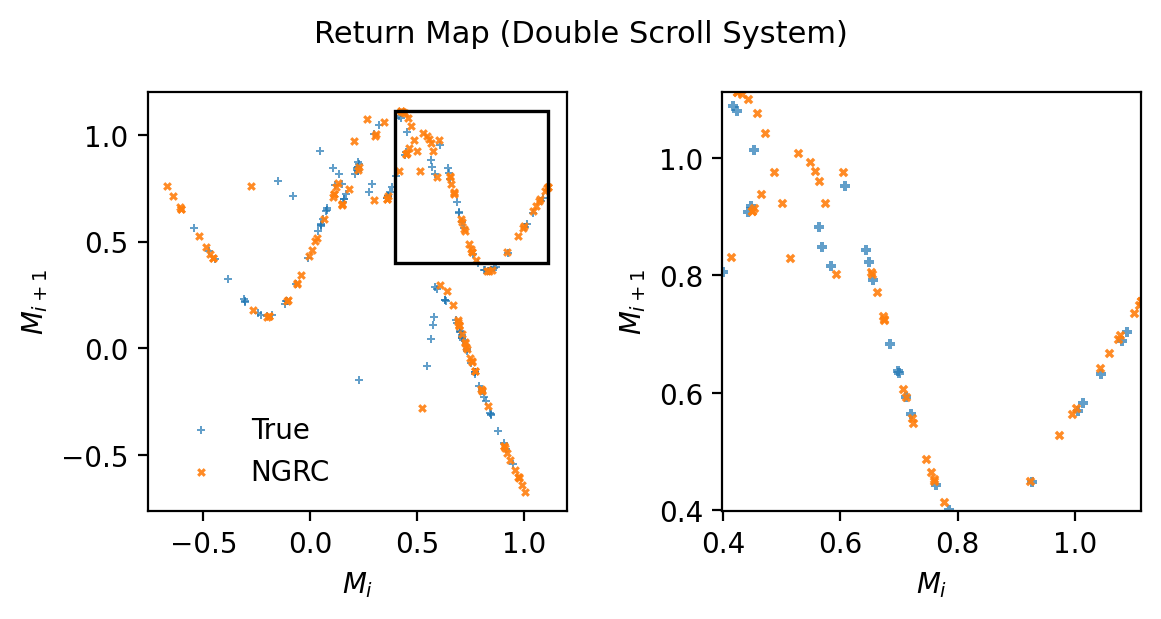

In [20]:
# Compute return maps using V2

rm = return_map_spline(x_test[1, :])

rm_cmp = return_map_spline(
    doublescroll_soln.y[1, warmtrain_pts:maxtime_pts]
)


# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, dpi=200, figsize=(6, 3))


# --- Whole return map ---
ax1.scatter(
    rm_cmp[:, 0], rm_cmp[:, 1],
    marker='P',
    s=10,
    color='tab:blue',
    alpha=0.7,
    linewidths=0,
    label='True'
)

ax1.scatter(
    rm[:, 0], rm[:, 1],
    marker='X',
    s=10,
    color='tab:orange',
    alpha=0.9,
    linewidths=0,
    label='NGRC'
)


# Dynamic limits
all_vals = np.concatenate([rm.flatten(), rm_cmp.flatten()])

vmin = np.min(all_vals)
vmax = np.max(all_vals)

margin = 0.05 * (vmax - vmin)

ax1.set_xlim(vmin - margin, vmax + margin)
ax1.set_ylim(vmin - margin, vmax + margin)

ax1.set_xlabel('$M_i$')
ax1.set_ylabel('$M_{i+1}$')
ax1.set_aspect('equal', adjustable='box')
ax1.legend(frameon=False)


# --- Zoomed return map ---
xlim2 = (vmin + 0.6 * (vmax - vmin), vmax)
ylim2 = (vmin + 0.6 * (vmax - vmin), vmax)

ax2.scatter(
    rm_cmp[:, 0], rm_cmp[:, 1],
    marker='P',
    s=12,
    color='tab:blue',
    alpha=0.7,
    linewidths=0
)

ax2.scatter(
    rm[:, 0], rm[:, 1],
    marker='X',
    s=12,
    color='tab:orange',
    alpha=0.9,
    linewidths=0
)

ax2.set_xlim(*xlim2)
ax2.set_ylim(*ylim2)

ax2.set_xlabel('$M_i$')
ax2.set_ylabel('$M_{i+1}$')
ax2.set_aspect('equal', adjustable='box')


# --- Draw zoom box ---
rect = matplotlib.patches.Rectangle(
    (xlim2[0], ylim2[0]),
    xlim2[1] - xlim2[0],
    ylim2[1] - ylim2[0],
    linewidth=1.2,
    edgecolor='black',
    facecolor='none'
)

ax1.add_patch(rect)


# Title (same style as Lorenz)
fig.suptitle('Return Map (Double Scroll System)', fontsize=11)


# Save and show
plt.tight_layout(pad=1.0)
plt.savefig('img/ds_return_map_v2.png', dpi=300, bbox_inches='tight')
plt.show()